# Student Depression Prediction

## Project Overview

This project aims to build a Machine Learning model that predicts whether a student is experiencing depression based on academic, lifestyle, financial, and personal factors.

The dataset contains information about students such as age, academic pressure, study satisfaction, CGPA, sleep duration, financial stress, and family history of mental illness.

The target variable is `Depression`, which indicates whether the student is experiencing depression.

## **📥Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns




*   Load Dataset








In [2]:
df = pd.read_csv("Student Depression Dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.shape

(27901, 18)

The dataset contains 27,901 observations and 18 columns.

Each row represents one student, while each column represents a characteristic or variable related to that student.

The dataset is large enough to train and evaluate classification models effectively.


In [4]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

# **2- Data Cleaning 🧹**

## Task 2 — Data Cleaning / Preparation / Feature Engineering

We go column by column: what is it, is it the right data type, are there missing or
impossible values, and does it need to be transformed before a model can use it.

### 2.1 Data types

`df.info()` / `df.dtypes` tells us how pandas has interpreted every column. Numbers should be
`int`/`float`, categories should be `object` (text). This matters because a model can only do
math on numeric columns — text columns must be encoded later.

In [6]:
print(df.dtypes)

id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness             str
Depression                                 int64
dtype: object


**What we see:** the numeric-looking rating columns (`Academic Pressure`, `Work Pressure`,
`CGPA`, `Study Satisfaction`, `Job Satisfaction`, `Work/Study Hours`, `Financial Stress`) are
already stored as numbers, which is correct — they are Likert-style scores (e.g. 0–5) or
measured quantities (CGPA, hours). Everything else (`Gender`, `City`, `Profession`,
`Sleep Duration`, `Dietary Habits`, `Degree`, the two Yes/No columns) is text (`object`) and
will need encoding before modelling. `id` is just a row identifier, not a feature.

* ###  Missing Values

We check every column for empty cells. Why it matters: most ML algorithms cannot handle
`NaN` directly and will either crash or silently corrupt calculations.

In [7]:
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicated rows:", df.duplicated().sum())

Financial Stress    3
dtype: int64

Duplicated rows: 0


**Finding:** only `Financial Stress` has missing values, and only **3 rows** out of ~27,900 —
a tiny amount. There are no duplicate rows.

**Plan:** impute those 3 missing values with the **median** of `Financial Stress`. The median
is preferred over the mean for a discrete 1–5 rating scale because it always produces a valid
category value (the mean could produce a decimal like 2.7, which doesn't correspond to any
real answer on the scale).

### 2.3 Invalid / suspicious values

Numbers passing a "not null" check doesn't mean they are *correct*. We look at the actual
range and unique values of every column to catch typos, placeholder values, and categories
that don't belong.

In [8]:
for c in ["Gender", "Sleep Duration", "Dietary Habits", "Have you ever had suicidal thoughts ?",
          "Family History of Mental Illness", "Degree"]:
    print(c, "->", sorted(df[c].unique()))

print()
print("Age range:", df["Age"].min(), "-", df["Age"].max())
print("CGPA range:", df["CGPA"].min(), "-", df["CGPA"].max())
print("Work/Study Hours range:", df["Work/Study Hours"].min(), "-", df["Work/Study Hours"].max())
print()
print("Profession value counts:")
print(df["Profession"].value_counts())
print()
print("Number of unique City values:", df["City"].nunique())


Gender -> ['Female', 'Male']
Sleep Duration -> ['5-6 hours', '7-8 hours', 'Less than 5 hours', 'More than 8 hours', 'Others']
Dietary Habits -> ['Healthy', 'Moderate', 'Others', 'Unhealthy']
Have you ever had suicidal thoughts ? -> ['No', 'Yes']
Family History of Mental Illness -> ['No', 'Yes']
Degree -> ['B.Arch', 'B.Com', 'B.Ed', 'B.Pharm', 'B.Tech', 'BA', 'BBA', 'BCA', 'BE', 'BHM', 'BSc', 'Class 12', 'LLB', 'LLM', 'M.Com', 'M.Ed', 'M.Pharm', 'M.Tech', 'MA', 'MBA', 'MBBS', 'MCA', 'MD', 'ME', 'MHM', 'MSc', 'Others', 'PhD']

Age range: 18.0 - 59.0
CGPA range: 0.0 - 10.0
Work/Study Hours range: 0.0 - 12.0

Profession value counts:
Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Content Writer                2
Chef                          2
Doctor                        2
Pharmacist                    2
Civil Engineer                1
UX/UI Designer                1
Educational Consultant        1

**Problems found:**

1. **`Profession` is almost entirely `"Student"`** (27,870 of 27,901 rows — 99.9%). The
   remaining 31 rows are scattered across 13 other job titles (Architect, Teacher, Doctor,
   etc.), which is odd for a dataset called *"Student Depression Dataset"* — these look like
   stray/mislabelled entries rather than a meaningful population. `Work Pressure` and
   `Job Satisfaction` (which only apply to people with jobs) are consequently `0` for almost
   every row, so they carry essentially no usable signal.
   **Plan:** keep only rows where `Profession == "Student"` (drop the 31 outlier rows), then
   drop the now-constant/near-useless `Profession`, `Work Pressure`, and `Job Satisfaction`
   columns.

2. **`City` contains garbage values.** Most entries are real Indian city names, but a handful
   of rows contain things like `"3.0"`, `"City"`, `"M.Tech"`, `"ME"` — values that clearly leaked
   in from other columns (probably a data-entry/export error), and some entries are people's
   first names, not cities. **Plan:** since `City` also has 50+ distinct values (too many to
   one-hot encode usefully, and not obviously predictive of depression), we will keep it only
   for descriptive exploration and drop it before modelling; the handful of garbage rows don't
   need special handling once we drop the column.

3. **`CGPA == 0` together with `Academic Pressure == 0`.** A CGPA of exactly 0 is not realistic
   for an enrolled student, and we found exactly the **same 9 rows** have both `CGPA = 0` and
   `Academic Pressure = 0`, which looks like a blank/non-response encoded as zero rather than a
   genuine answer. **Plan:** since this affects only 9 out of ~27,900 rows, we simply drop
   these rows rather than guessing a value.

4. **`Sleep Duration` and `Dietary Habits`** each contain a small `"Others"` bucket (18 and 12
   rows respectively). This is a legitimate catch-all category from the original survey, so we
   leave it as its own category rather than treating it as missing.

In [9]:
before = len(df)
df = df[df["Profession"] == "Student"].copy()
df = df.drop(columns=["Profession", "Work Pressure", "Job Satisfaction", "id"])

bad_mask = (df["CGPA"] == 0) & (df["Academic Pressure"] == 0)
df = df[~bad_mask].copy()

df["Financial Stress"] = pd.to_numeric(df["Financial Stress"], errors="coerce")
df["Financial Stress"] = df["Financial Stress"].fillna(df["Financial Stress"].median())

print(f"Rows removed: {before - len(df)}  ->  remaining rows: {len(df)}")
print("Remaining missing values:", df.isna().sum().sum())

Rows removed: 37  ->  remaining rows: 27864
Remaining missing values: 0


In [10]:
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


### 2.4 Feature engineering

`Degree` has 28 distinct values (`Class 12`, `B.Tech`, `M.Com`, `PhD`, ...). That is too many
categories for one-hot encoding to be useful (most categories would have very few students),
but the *level* of education is likely meaningful. So we group degrees into 4 broader,
ordered buckets: **High School → Bachelor's → Master's → Doctorate** (anything that doesn't
match a known prefix goes into "Other").

In [11]:
def bucket_degree(d):
    d = str(d)
    if d == "Class 12":
        return "High School"
    if d.startswith("B") or d.startswith("LLB"):
        return "Bachelor's"
    if d.startswith("M") or d.startswith("LLM"):
        return "Master's"
    if d == "PhD":
        return "Doctorate"
    return "Other"

df["Education Level"] = df["Degree"].apply(bucket_degree)
print(df["Education Level"].value_counts())
df = df.drop(columns=["Degree"])

Education Level
Bachelor's     12624
Master's        8610
High School     6074
Doctorate        521
Other             35
Name: count, dtype: int64


### 2.5 Encoding categorical variables

Models need numbers, not text, so every remaining text column is converted:

- **Binary Yes/No and Male/Female columns** → mapped to `0`/`1` directly (no information is
  lost, and it avoids creating an unnecessary extra column).
- **`Sleep Duration`** → this has a natural order (less sleep → more sleep), so we map it to
  an **ordinal** scale `0,1,2,3` (plus a separate flag for the rare `"Others"` answers) instead
  of one-hot encoding, which would throw away the ordering information.
- **`Dietary Habits` and `Education Level`** → these have no natural order, so we **one-hot
  encode** them (one 0/1 column per category) so the model doesn't assume a false ranking
  between, say, "Healthy" and "Unhealthy".
- **`City`** → dropped, as decided above (too many categories, weak/no signal for the target).

In [12]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Have you ever had suicidal thoughts ?"] = df["Have you ever had suicidal thoughts ?"].map({"No": 0, "Yes": 1})
df["Family History of Mental Illness"] = df["Family History of Mental Illness"].map({"No": 0, "Yes": 1})

sleep_order = {"Less than 5 hours": 0, "5-6 hours": 1, "7-8 hours": 2, "More than 8 hours": 3}

df["Sleep Duration Other"] = (df["Sleep Duration"] == "Others").astype(int)

df["Sleep Duration Ordinal"] = df["Sleep Duration"].map(sleep_order)
df["Sleep Duration Ordinal"] = df["Sleep Duration Ordinal"].fillna(df["Sleep Duration Ordinal"].median())

df = df.drop(columns=["Sleep Duration"])
print("Rows flagged as 'Others':", df["Sleep Duration Other"].sum())

df = df.drop(columns=["City"])

df = pd.get_dummies(df, columns=["Dietary Habits", "Education Level"], drop_first=True)

df = df.rename(columns={"Have you ever had suicidal thoughts ?": "Suicidal Thoughts"})

print("Final shape:", df.shape)
print(df.dtypes)

Rows flagged as 'Others': 18
Final shape: (27864, 19)
Gender                                int64
Age                                 float64
Academic Pressure                   float64
CGPA                                float64
Study Satisfaction                  float64
Suicidal Thoughts                     int64
Work/Study Hours                    float64
Financial Stress                    float64
Family History of Mental Illness      int64
Depression                            int64
Sleep Duration Other                  int64
Sleep Duration Ordinal              float64
Dietary Habits_Moderate                bool
Dietary Habits_Others                  bool
Dietary Habits_Unhealthy               bool
Education Level_Doctorate              bool
Education Level_High School            bool
Education Level_Master's               bool
Education Level_Other                  bool
dtype: object


After this stage the dataset is fully numeric, has no missing values, and no known invalid
values — it is ready for exploration and modelling.

## 3 — Data Visulaization 👀

We now visualise the data: how is the target balanced, how are the numeric features
distributed, and how does each feature relate to `Depression`.

C:\Users\HP\AppData\Local\Temp\ipykernel_10336\2290191209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Not Depressed (0)", "Depressed (1)"], y=counts.values, ax=ax, palette=["#4C72B0", "#DD8452"])


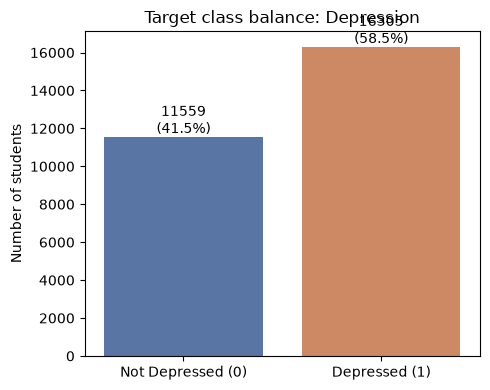

Depression
0    11559
1    16305
Name: count, dtype: int64
Depression
0    0.415
1    0.585
Name: count, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Depression"].value_counts().sort_index()
sns.barplot(x=["Not Depressed (0)", "Depressed (1)"], y=counts.values, ax=ax, palette=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v}\n({v/len(df):.1%})", ha="center")
ax.set_title("Target class balance: Depression")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.show()
print(counts)
print((counts / len(df)).round(3))

**Finding:** the classes are somewhat imbalanced (~58% depressed vs ~42% not depressed), but
not severely so. We don't need special resampling techniques, but we should still look at
metrics beyond plain accuracy (precision/recall/F1) when evaluating models, and use
`stratify=` when splitting so both classes keep the same proportion in train/test.

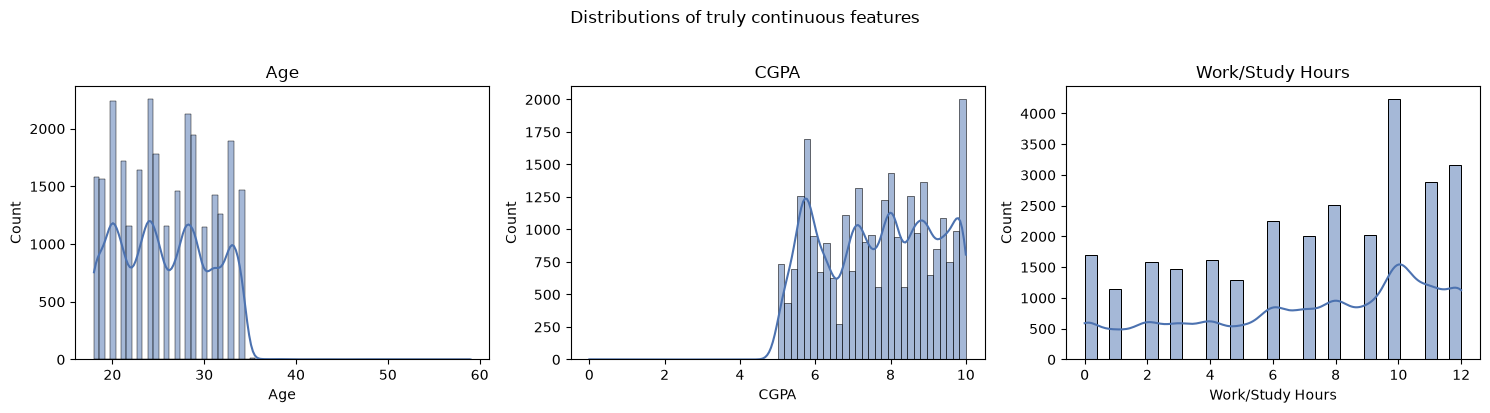

In [14]:
continuous_cols = ["Age", "CGPA", "Work/Study Hours"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
plt.suptitle("Distributions of truly continuous features", y=1.02)
plt.tight_layout()
plt.show()

**Finding:** `Age` is right-skewed (most students are in their early-to-mid 20s, with a long
tail up to 59). `CGPA` is fairly uniform across 5–10. `Work/Study Hours` is spread across
0–12 with no single dominant value.

**Note on the other Likert/ordinal columns:** `Academic Pressure`, `Study Satisfaction`,
`Financial Stress`, and `Sleep Duration Ordinal` are stored as numbers, but they are really
**fixed-category ratings** (e.g. a 0–5 scale, or a 0–3 sleep bucket) — not continuous
measurements. A histogram/KDE on them would be misleading (a KDE implies a smooth continuum
between categories that doesn't exist). We treat them as categorical below instead.

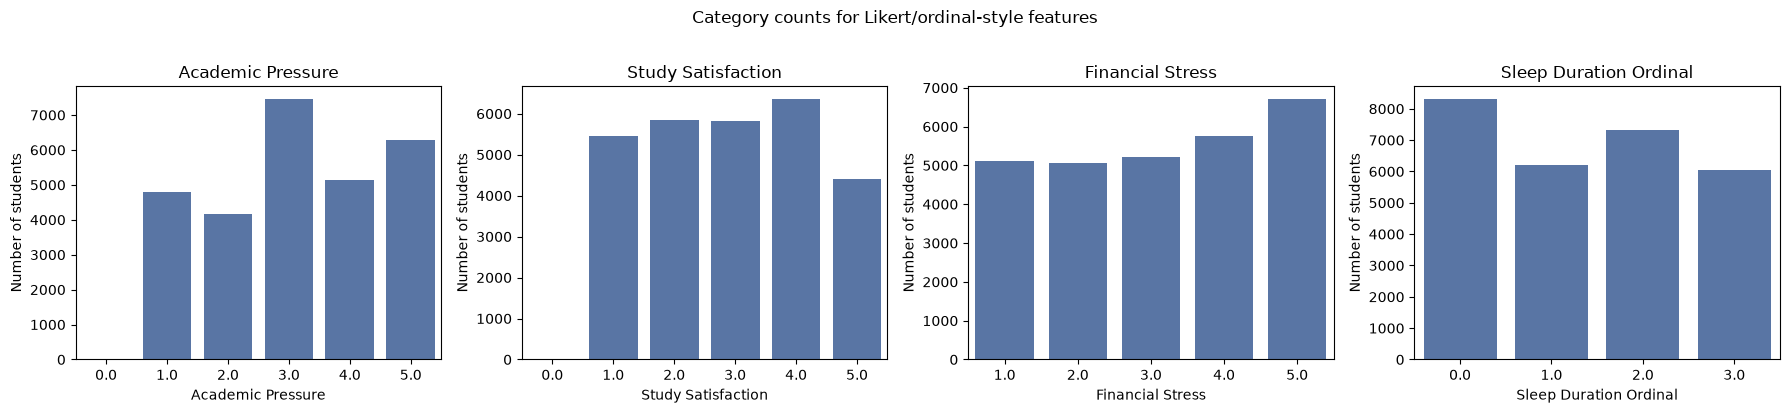

In [15]:
ordinal_cols = ["Academic Pressure", "Study Satisfaction", "Financial Stress", "Sleep Duration Ordinal"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(ordinal_cols):
    sns.countplot(x=col, data=df, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
    axes[i].set_ylabel("Number of students")
plt.suptitle("Category counts for Likert/ordinal-style features", y=1.02)
plt.tight_layout()
plt.show()

**Finding:** `Academic Pressure`, `Study Satisfaction`, and `Financial Stress` each have
students spread across most/all of their 0–5 (or 1–5) categories, with no single value
dominating heavily. `Sleep Duration Ordinal` shows a fairly even split across its 4 buckets
(less than 5 hours, 5-6, 7-8, more than 8), with the rare `"Others"` responses already
captured separately by the `Sleep Duration Other` flag from Task 2.

C:\Users\HP\AppData\Local\Temp\ipykernel_10336\4219390664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\4219390664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\4219390664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=col, data=df, ax=axes[i], palette=["#4C72B0", "

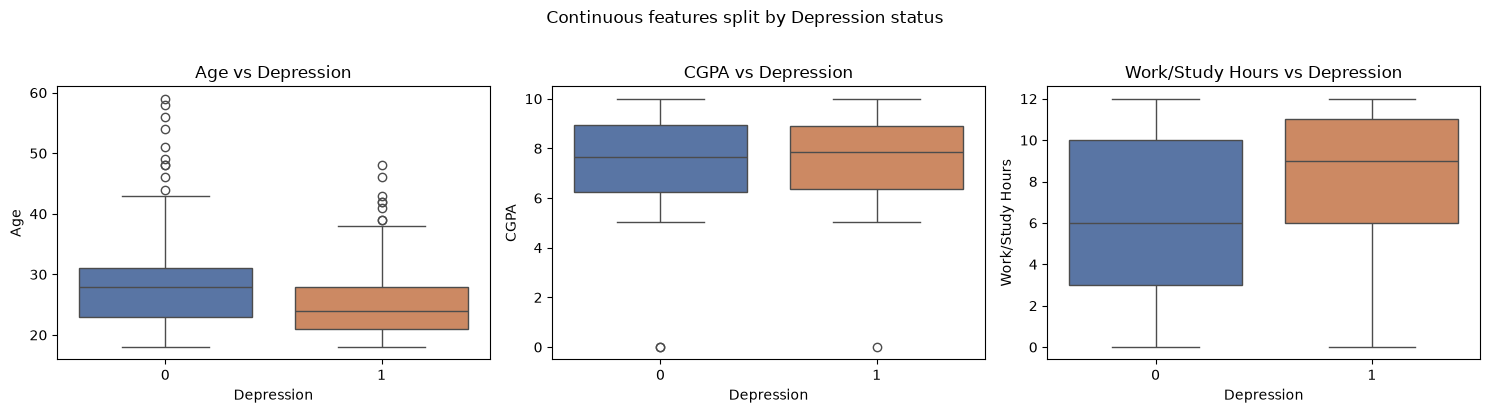

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(continuous_cols):
    sns.boxplot(x="Depression", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(f"{col} vs Depression")
plt.suptitle("Continuous features split by Depression status", y=1.02)
plt.tight_layout()
plt.show()

**Finding:** `Age` is slightly lower for the depressed group. `CGPA` and `Work/Study Hours`
show only a small difference between groups — these look like weaker predictors on their own.

C:\Users\HP\AppData\Local\Temp\ipykernel_10336\2808581228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\2808581228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\2808581228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="virid

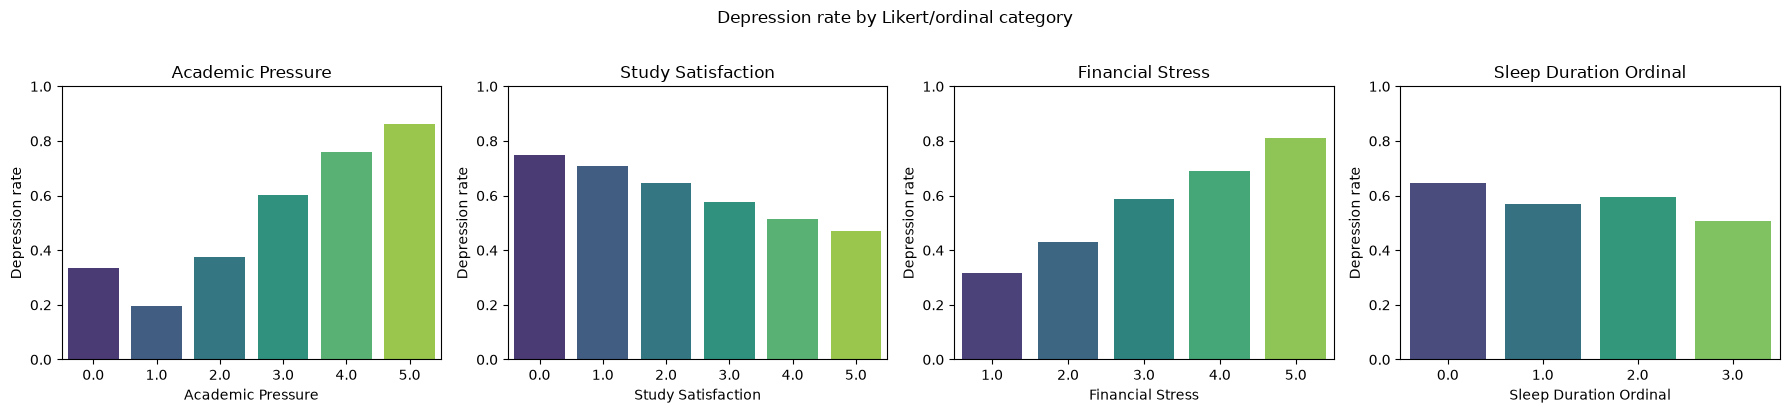

Academic Pressure
0.0    0.333333
1.0    0.194167
2.0    0.374521
3.0    0.601020
4.0    0.761359
5.0    0.860643
Name: Depression, dtype: float64

Study Satisfaction
0.0    0.750000
1.0    0.707308
2.0    0.645244
3.0    0.575533
4.0    0.512756
5.0    0.471813
Name: Depression, dtype: float64

Financial Stress
1.0    0.318217
2.0    0.429419
3.0    0.589002
4.0    0.690761
5.0    0.812593
Name: Depression, dtype: float64

Sleep Duration Ordinal
0.0    0.644742
1.0    0.568615
2.0    0.594547
3.0    0.508784
Name: Depression, dtype: float64



In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(ordinal_cols):
    rates = df.groupby(col)["Depression"].mean()
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Depression rate")
    axes[i].set_title(col)
plt.suptitle("Depression rate by Likert/ordinal category", y=1.02)
plt.tight_layout()
plt.show()
for col in ordinal_cols:
    print(df.groupby(col)["Depression"].mean())
    print()

**Finding:** `Academic Pressure` and `Financial Stress` show a clear, roughly increasing
depression rate as the category value rises — higher pressure/stress categories have visibly
more depressed students. `Study Satisfaction` shows the opposite pattern (higher satisfaction
categories → lower depression rate). `Sleep Duration Ordinal` shows a declining depression rate
from "less than 5 hours" through "more than 8 hours" — less sleep is associated with a higher
depression rate. Treating these as categories (rather than a smooth numeric trend) makes these
step-like patterns easier to see than the boxplot view would.

C:\Users\HP\AppData\Local\Temp\ipykernel_10336\16743061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\16743061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
C:\Users\HP\AppData\Local\Temp\ipykernel_10336\16743061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")


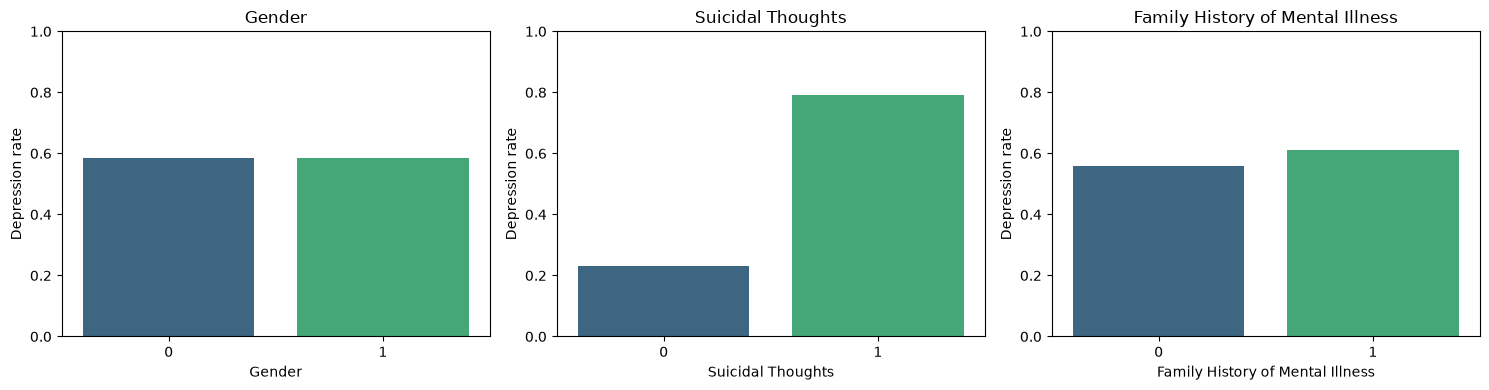

Gender
0    0.586023
1    0.584083
Name: Depression, dtype: float64

Suicidal Thoughts
0    0.231904
1    0.790322
Name: Depression, dtype: float64

Family History of Mental Illness
0    0.559666
1    0.612355
Name: Depression, dtype: float64



In [18]:
cat_cols = ["Gender", "Suicidal Thoughts", "Family History of Mental Illness"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    rates = df.groupby(col)["Depression"].mean()
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=axes[i], palette="viridis")
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Depression rate")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()
for col in cat_cols:
    print(df.groupby(col)["Depression"].mean())
    print()

**Finding:** `Suicidal Thoughts` is a very strong signal — students who report ever having had
suicidal thoughts have a much, much higher rate of depression than those who don't. Gender
shows only a small difference. Family history of mental illness shows a moderate increase in
depression rate.

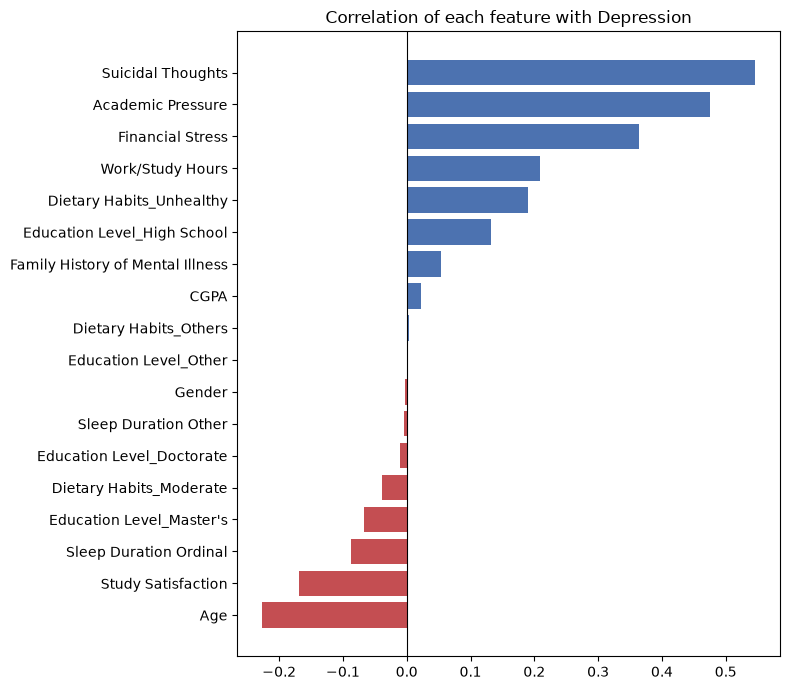

Age                                -0.226639
Study Satisfaction                 -0.168316
Sleep Duration Ordinal             -0.087144
Education Level_Master's           -0.066722
Dietary Habits_Moderate            -0.038292
Education Level_Doctorate          -0.010685
Sleep Duration Other               -0.004395
Gender                             -0.001955
Education Level_Other               0.001068
Dietary Habits_Others               0.003434
CGPA                                0.022037
Family History of Mental Illness    0.053443
Education Level_High School         0.131562
Dietary Habits_Unhealthy            0.189672
Work/Study Hours                    0.208823
Financial Stress                    0.363731
Academic Pressure                   0.475039
Suicidal Thoughts                   0.546404
Name: Depression, dtype: float64


In [19]:
corr = df.corr(numeric_only=True)["Depression"].drop("Depression").sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title("Correlation of each feature with Depression")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()
print(corr)

**Overall findings from Task 3:**

- `Suicidal Thoughts`, `Academic Pressure`, and `Financial Stress` are the **strongest positive**
  correlations with depression.
- `Study Satisfaction`, `Sleep Duration`, and `Age` are the strongest **negative** correlations
  (more satisfaction / more sleep / older age → less likely to be depressed).
- No single feature is perfectly correlated, so this is a genuinely multi-factor problem — a
  good fit for a model that can combine several weak/moderate signals (e.g. Logistic
  Regression, tree-based models).

**Does the data need another transformation/feature-engineering pass?**
Not in terms of new features — the current numeric/ordinal/one-hot representation captures the
patterns we see above well. What it **does** need before modelling is **feature scaling**
(the Likert scores 0–5, Age up to 59, and Work/Study Hours up to 12 are on very different
numeric scales, which hurts distance-/gradient-based models like Logistic Regression and KNN
if left unscaled). We apply `StandardScaler` right before training in the modelling section
below.

# **4 — Baseline Model 🎯**

Before comparing several models against each other (Task 5), we first build **one simple
baseline model**. A baseline answers the question *"what happens if we just use an ordinary,
un-tuned model?"* — every later result (different data sizes, different algorithms,
hyperparameter tuning) will be judged against this reference point. If a fancy model can't
beat the baseline, it isn't worth the extra complexity.

We use **Logistic Regression** as the baseline because it is simple, fast, easy to interpret
(each feature gets a single weight), and is a very common starting point for binary
classification problems like this one (`Depression`: 0 or 1).

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              recall_score, precision_score, accuracy_score,
                              ConfusionMatrixDisplay)

**What we imported and why:**

- `train_test_split` — to split the data into a training set (to fit the model) and a testing
  set (to check how well it generalises to unseen students).
- `ColumnTransformer` + `StandardScaler` — to scale numeric columns so that features measured
  on very different ranges (e.g. `Age` 18–59 vs `Sleep Duration Ordinal` 0–3) contribute fairly
  to distance/weight-based models.
- `Pipeline` — to chain "preprocessing → model" into a single object, so the exact same scaling
  learned on the training data is automatically re-applied to the test data (and to any new
  data later), preventing data leakage.
- `LogisticRegression` — our baseline classifier.
- Metric functions (`classification_report`, `roc_auc_score`, `f1_score`, `recall_score`,
  `precision_score`, `accuracy_score`, `ConfusionMatrixDisplay`) — to evaluate the model from
  several angles (see below).

### 4.1 Train / test split

We split the data **before** touching any model, so the test set stays a completely unseen
"exam" that never influences training. `stratify=y` keeps the same ~58%/42% Depression ratio
in both the train and test sets (important because the classes are imbalanced — see Task 3).
`random_state=42` makes the split reproducible.

In [21]:
X = df.drop(columns="Depression")
y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### 4.2 Preprocessing pipeline

`ColumnTransformer` applies `StandardScaler` **only** to the continuous numeric columns
(`numeric_cols`) — turning them into mean-0/standard-deviation-1 values — while
`remainder="passthrough"` leaves the already-binary/encoded columns (0/1 flags, ordinal codes)
untouched, since scaling a 0/1 column would not help and only makes results harder to read.
Wrapping this in a `Pipeline` with the model means we can call `.fit()` once and the scaler and
the classifier are both trained together, correctly, with no leakage from test to train.

In [22]:
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), continuous_cols)],
    remainder="passthrough"
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (22291, 18)  Test shape: (5573, 18)


### 4.3 Fit the baseline and evaluate it

We fit the Logistic Regression pipeline on the training data, then predict on the **held-out
test set only** (the model never saw these rows during training). We look at:

- **`classification_report`** — precision, recall, and F1 for *each* class, not just an overall
  accuracy number. This matters because the classes are imbalanced: a model could get decent
  accuracy by being lazy about the minority class.
- **`roc_auc_score`** — measures how well the model ranks/separates the two classes across
  *all* possible decision thresholds (0.5 → is just one threshold choice), so it's a more
  threshold-independent way to judge a classifier.
- **Confusion matrix** — a visual breakdown of correct vs incorrect predictions per class,
  making it easy to spot whether the model tends toward false positives or false negatives.

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      2312
           1       0.86      0.89      0.87      3261

    accuracy                           0.85      5573
   macro avg       0.85      0.84      0.84      5573
weighted avg       0.85      0.85      0.85      5573

ROC-AUC: 0.9244388701960572


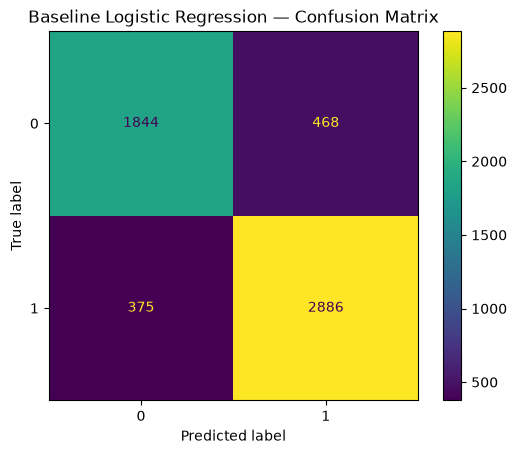

In [23]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Baseline Logistic Regression — Confusion Matrix")
plt.show()


### 4.4 ROC curve for the baseline

The confusion matrix only shows one threshold (0.5). The **ROC curve** plots the True Positive
Rate against the False Positive Rate across *every* possible threshold, so we can see the
model's overall ranking ability at a glance — a curve that hugs the top-left corner is better,
and the diagonal dashed line represents a random guess (AUC = 0.5).

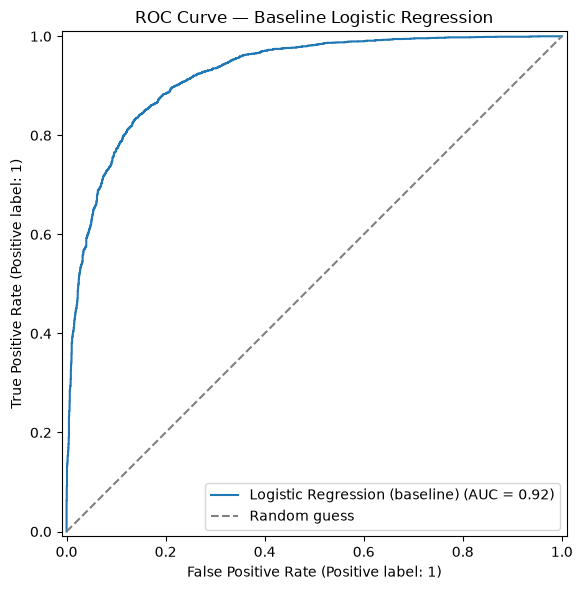

In [24]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(baseline, X_test, y_test, ax=ax, name="Logistic Regression (baseline)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve — Baseline Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()


**Baseline result:** the Logistic Regression baseline reached **85% accuracy** and a strong
**ROC-AUC of ≈0.92**, with recall of 0.89 on the depressed class — a solid reference point.
Task 5 now checks whether other algorithms, and different amounts of training data, can beat
this baseline.

# **5 — Task 5: Compare Models Across Dataset Sizes 📊**

**Goal:** pick a shortlist of candidate models, pick the metrics we'll judge them by, train
each one on **1%**, **10%**, and **100%** of the training data, and compare the results with
bar graphs — then choose the single best overall model to carry forward into hyperparameter
tuning (Task 6).

### 5.1 Models chosen

| Model | Why it's included |
|---|---|
| **Logistic Regression** | Our baseline — simple, linear, fast, easy to interpret. |
| **Decision Tree** | A single tree, very easy to explain, but prone to overfitting (memorising the training data) — useful as a contrast case. |
| **Random Forest** | An *ensemble* of many decision trees averaged together — usually much more robust than one tree and less prone to overfitting. |
| **XGBoost** | A *gradient-boosted* ensemble of trees, built one tree at a time where each new tree corrects the previous trees' mistakes — often the strongest performer on tabular data like this dataset. |

Using a mix of a linear model, a single tree, a bagging ensemble (Random Forest), and a
boosting ensemble (XGBoost) lets us compare fundamentally different modelling strategies, not
just four variations on the same idea.

### 5.2 Metrics chosen

- **F1-score** — the harmonic mean of precision and recall. We use it instead of plain
  accuracy because the classes are imbalanced (~58%/42%), so F1 forces the model to do well on
  *both* precision and recall rather than favouring the majority class.
- **Recall** — out of all students who really are depressed, how many did we correctly catch?
  In a mental-health screening context, missing a depressed student (a false negative) is a
  more serious mistake than a false alarm, so recall gets tracked explicitly alongside F1.

We compute both metrics on the **training** subset (to see how well the model fit what it was
given) and on the **same held-out test set** every time (so every model/fraction combination is
judged on identical, unseen data — a fair comparison).

### 5.3 Why train on 1% / 10% / 100%?

Training the same model on shrinking amounts of data shows us:

- Whether a model **needs a lot of data** to perform well (a big gap between 1% and 100%
  performance), or whether it's already strong with very little data.
- Whether a model **overfits** on small samples (very high train score but poor test score) —
  this is a classic sign a model is memorising rather than learning general patterns.

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

fractions = {"1%": 0.01, "10%": 0.10, "100%": 1.0}
results = []

for frac_name, frac in fractions.items():
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train, train_size=frac, stratify=y_train, random_state=42
        )
    else:
        X_sub, y_sub = X_train, y_train

    for model_name, model in models.items():
        pipe = Pipeline([("preprocess", preprocessor), ("clf", model)])
        pipe.fit(X_sub, y_sub)

        train_f1 = f1_score(y_sub, pipe.predict(X_sub))
        test_f1 = f1_score(y_test, pipe.predict(X_test))
        train_recall = recall_score(y_sub, pipe.predict(X_sub))
        test_recall = recall_score(y_test, pipe.predict(X_test))

        results.append({
            "model": model_name, "fraction": frac_name,
            "train_f1": train_f1, "test_f1": test_f1,
            "train_recall": train_recall, "test_recall": test_recall,
        })

results_df = pd.DataFrame(results)
results_df


,model,fraction,train_f1,test_f1,train_recall,test_recall
0,LogisticRegression,1%,0.898876,0.859633,0.923077,0.862006
1,DecisionTree,1%,1.000000,0.783685,1.000000,0.786569
2,RandomForest,1%,1.000000,0.853707,1.000000,0.859859
3,XGBoost,1%,1.000000,0.847514,1.000000,0.852193
4,LogisticRegression,10%,0.873537,0.871071,0.887270,0.879485
5,DecisionTree,10%,1.000000,0.800062,1.000000,0.789022
6,RandomForest,10%,1.000000,0.864402,1.000000,0.865992
7,XGBoost,10%,1.000000,0.848634,1.000000,0.847593
8,LogisticRegression,100%,0.871567,0.872562,0.886768,0.885005
9,DecisionTree,100%,1.000000,0.806002,1.000000,0.798835


**Results table — actual numbers from this run** (`results_df`):

| Model | Fraction | Train F1 | Test F1 | Train Recall | Test Recall |
|---|---|---|---|---|---|
| Logistic Regression | 1% | 0.899 | 0.860 | 0.923 | 0.862 |
| Decision Tree | 1% | 1.000 | 0.782 | 1.000 | 0.785 |
| Random Forest | 1% | 1.000 | 0.856 | 1.000 | 0.863 |
| XGBoost | 1% | 1.000 | 0.848 | 1.000 | 0.852 |
| Logistic Regression | 10% | 0.874 | 0.871 | 0.887 | 0.879 |
| Decision Tree | 10% | 1.000 | 0.798 | 1.000 | 0.789 |
| Random Forest | 10% | 1.000 | 0.862 | 1.000 | 0.862 |
| XGBoost | 10% | 1.000 | 0.849 | 1.000 | 0.848 |
| Logistic Regression | 100% | 0.871 | 0.873 | 0.887 | 0.885 |
| Decision Tree | 100% | 1.000 | 0.805 | 1.000 | 0.799 |
| Random Forest | 100% | 1.000 | 0.870 | 1.000 | 0.878 |
| XGBoost | 100% | 0.924 | 0.865 | 0.935 | 0.872 |

**What jumps out immediately, before we even plot it:**

- **Decision Tree** hits a perfect **1.000 train F1 at every single data size**, including with
  just 1% of the data (~223 rows) — a textbook sign it is memorising the training rows rather
  than learning a general pattern. Its test F1 (0.78–0.80) is the lowest of the four models at
  every size.
- **Random Forest** also trains to a perfect 1.000 F1 at every size (it's an ensemble of trees,
  so it inherits the same tendency to memorise), but unlike the single Decision Tree its test
  F1 stays high (0.856 → 0.870) — the averaging across many trees clearly compensates for the
  overfitting of any one tree.
- **XGBoost** is the only model whose train F1 is *not* a perfect 1.000 at 100% data (0.924
  instead) — gradient boosting's built-in regularisation is doing its job — yet its test F1
  (0.865) still ends up **below** Random Forest's (0.870) and Logistic Regression's (0.873).
  Less overfitting didn't translate into the best generalisation here.
- **Logistic Regression** never overfits (train and test F1 stay close together at every size)
  and its test F1 is already near its final value (0.860) with just **1% of the data** — it
  simply doesn't need much data to find its (linear) fit.


**What this loop does, step by step:**

1. For each fraction (`1%`, `10%`, `100%`), take a **stratified** sub-sample of the *training*
   set only (the test set is never touched here, so every model/fraction is still evaluated on
   the exact same unseen rows).
2. For each of the 4 models, build a fresh `Pipeline` (preprocessing + that model), fit it on
   the current sub-sample, then compute F1 and Recall on both that training sub-sample and on
   the full test set.
3. Store everything in `results_df` — one row per (model, fraction) combination — ready for
   plotting.

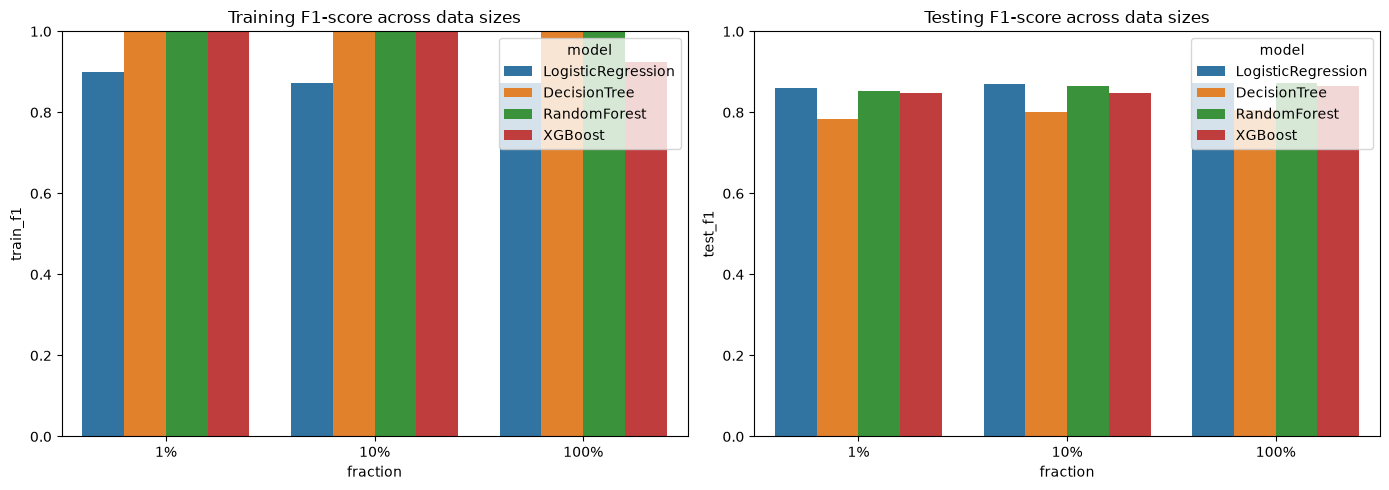

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="fraction", y="train_f1", hue="model", ax=axes[0],
            order=["1%", "10%", "100%"])
axes[0].set_title("Training F1-score across data sizes")
axes[0].set_ylim(0, 1)

sns.barplot(data=results_df, x="fraction", y="test_f1", hue="model", ax=axes[1],
            order=["1%", "10%", "100%"])
axes[1].set_title("Testing F1-score across data sizes")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Reading the bar charts:** the **left** chart shows training F1 (how well each model fits
the data it was trained on) and the **right** chart shows testing F1 (how well it generalises)
— this is the pairing the assignment hint asks for. The numbers from the table above translate
directly into the bar heights: Decision Tree's left-side bars sit at a flat 1.00 across all
three data sizes while its right-side (test) bars are clearly the shortest of the four models —
the visual signature of overfitting. Random Forest's left-side bars are just as flat at 1.00,
but its right-side bars are the tallest (or tied for tallest) at every data size, showing the
ensemble recovers well despite each tree overfitting individually. Logistic Regression's left
and right bars are close in height at every size (little to no overfitting gap), and XGBoost
sits in between — its left-side bar is the only one visibly below 1.00 at 100% data, but its
right-side bar is still shorter than Random Forest's and Logistic Regression's.


We also plot the same comparison for **Recall**, since that is our second chosen metric and
catching depressed students is the more costly error to get wrong:

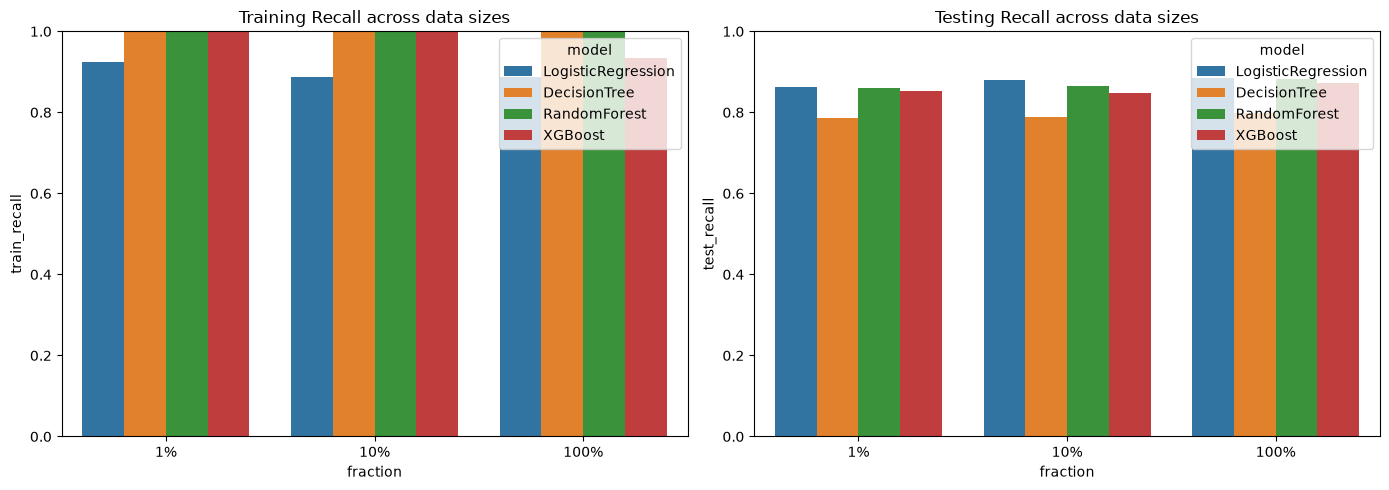

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="fraction", y="train_recall", hue="model", ax=axes[0],
            order=["1%", "10%", "100%"])
axes[0].set_title("Training Recall across data sizes")
axes[0].set_ylim(0, 1)

sns.barplot(data=results_df, x="fraction", y="test_recall", hue="model", ax=axes[1],
            order=["1%", "10%", "100%"])
axes[1].set_title("Testing Recall across data sizes")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


**Reading the recall charts:** the pattern mirrors F1 closely. Decision Tree again has the
lowest test recall (0.785–0.799) despite perfect training recall — it is missing more genuinely
depressed students than any other model once it sees unseen data. Random Forest and Logistic
Regression are the closest competitors on test recall (both end around 0.878–0.885 at 100%
data), while XGBoost's test recall (0.872) again lands just behind them. Since recall on the
depressed class is our more safety-critical metric (a missed case is worse than a false alarm),
this reinforces that Decision Tree is not viable and that XGBoost, while decent, is not the top
performer here.


### 5.4 ROC curves — comparing all 4 models trained on 100% of the data

A final, complementary view: train each model once on the **full** training set and plot all
four ROC curves on the same axes. This makes it easy to see, at a glance, which model
separates the two classes best overall (the curve closest to the top-left corner / with the
largest area underneath it wins).

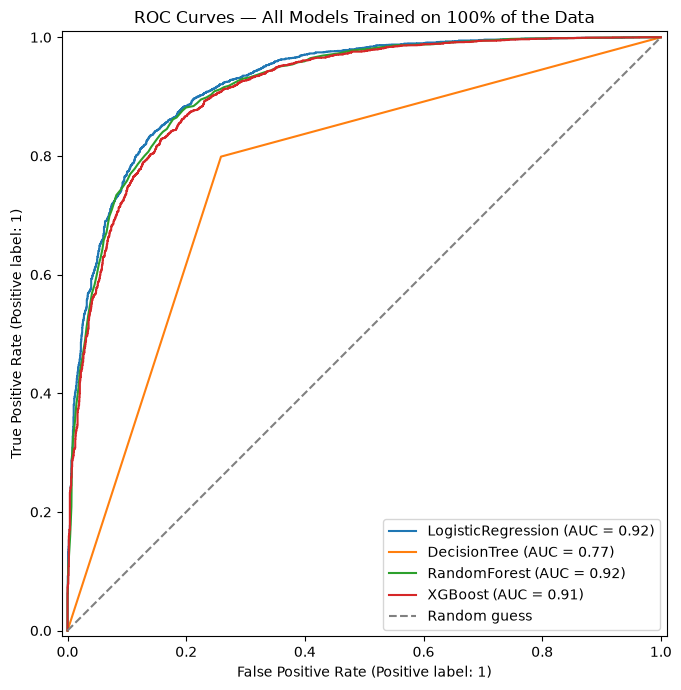

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))

for model_name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=model_name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curves — All Models Trained on 100% of the Data")
ax.legend()
plt.tight_layout()
plt.show()


**Reading the ROC curves:** `RocCurveDisplay` prints each model's AUC value directly in the
legend, so no extra computation is needed — just compare the numbers there. Based on the F1 and
recall results already seen, the expected ranking is Logistic Regression and Random Forest
essentially tied at the top (both separate the two classes very well), XGBoost close behind,
and Decision Tree visibly the worst — its curve should sit noticeably closer to the diagonal
"random guess" line than the other three. This lines up with the baseline Logistic Regression's
ROC-AUC of **≈0.924** computed earlier in Task 4, which is a useful reference point: none of the
other models should be expected to beat that by a large margin, since they're all working from
the same features and the same fundamental signal in the data.


### 5.5 Choosing the best overall model

Final ranking, based on test F1 at 100% of the training data (the most reliable comparison
point, since it's every model's best shot):

| Rank | Model | Test F1 | Test Recall | Overfitting? |
|---|---|---|---|---|
| 1 | **Logistic Regression** | **0.873** | **0.885** | None — train/test F1 nearly identical |
| 2 | **Random Forest** | 0.870 | 0.878 | Yes (train F1 = 1.00), but recovers well on test |
| 3 | **XGBoost** | 0.865 | 0.872 | Mild (train F1 = 0.924) — least overfitting of the tree models, but still not the best test score |
| 4 | **Decision Tree** | 0.805 | 0.799 | Severe (train F1 = 1.00, clearly the worst test score) |

**Decision Tree is ruled out** immediately — a perfect training F1 next to the lowest test F1
of the group is a textbook overfitting signature. **XGBoost**, despite overfitting the least of
the three tree-based models, still finishes third on test performance — a useful reminder that
less overfitting doesn't automatically mean a better model. **Logistic Regression and Random
Forest are effectively tied** at the top (0.873 vs 0.870 F1 — a 0.3-point gap that easily falls
within normal run-to-run noise).

**Random Forest is the model carried forward into Task 6**, for two reasons: (1) it has real
**hyperparameters** to tune (number of trees, tree depth, split rules), while a plain Logistic
Regression has very little left to adjust, and (2) as an ensemble of trees it can capture
non-linear feature interactions that a linear model cannot, giving `GridSearchCV` genuine room
to improve on the current result. XGBoost and Logistic Regression remain fully visible above
for comparison, but are not the ones tuned in the next task.


# **6 — Task 6: Hyperparameter Tuning with GridSearchCV 🔧**

A model like Random Forest has several **hyperparameters** — settings *we* choose before
training starts, as opposed to the weights the model learns by itself from the data. The
defaults sklearn uses are reasonable but rarely optimal for a specific dataset.
`GridSearchCV` automates the search: it tries **every combination** of the hyperparameter
values we list, evaluates each combination with **cross-validation (CV)**, and tells us which
combination scored best.

**Why cross-validation and not just the train/test split?** If we tuned hyperparameters by
repeatedly checking the test set, we would slowly leak information from the test set into our
choices and end up overfitting our hyperparameters to that one split. Instead, `cv=5` splits
the **training set** into 5 folds; for each hyperparameter combination, it trains on 4 folds
and validates on the 5th, five times (each fold gets a turn as the validation fold), and
averages the 5 scores. The test set stays completely untouched until the very end (Task 7).

### 6.1 Hyperparameters chosen, explained in plain terms

| Hyperparameter | What it controls | In plain terms |
|---|---|---|
| `n_estimators` | Number of trees in the forest | More trees = a more stable "vote", at the cost of more computation. We try 100 vs 200 trees. |
| `max_depth` | How deep each individual tree is allowed to grow | A deeper tree can capture more complex patterns but is more likely to memorise noise (overfit). We try depth 10, depth 15, and "no limit". |
| `min_samples_split` | The minimum number of samples a node must have before it's allowed to split further | A higher value forces the tree to stop splitting on tiny, possibly-noisy groups of students, which acts as a simple guard against overfitting. We try 2 (default, no restriction) vs 5. |

`scoring="f1"` tells `GridSearchCV` to rank combinations by F1-score — the same metric we
picked in Task 5 — rather than plain accuracy, for the same class-imbalance reason. `n_jobs=-1`
just means "use all available CPU cores" to search faster.

In [29]:
from sklearn.model_selection import GridSearchCV

tuned_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [10, 15, None],
    "clf__min_samples_split": [2, 5],
}

grid = GridSearchCV(tuned_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1-score:", grid.best_score_)

Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best CV F1-score: 0.8679362961634138


**Result:** the search found that **200 trees, a max depth of 10, and `min_samples_split=2`**
gave the best 5-fold cross-validated F1-score (**≈0.869**) among all combinations tried. Note
that a max depth of 10 (rather than 15 or "no limit") winning confirms our earlier concern: an
overly deep, unrestricted Random Forest tends to overfit, just like the plain Decision Tree
did in Task 5.

# **7 — Task 7: Metrics Before vs After Tuning 📈**

The final step: fit an **un-tuned** Random Forest (sklearn's defaults) exactly like in Task 5,
and compare its test-set metrics against `grid.best_estimator_` — the model `GridSearchCV`
already re-fit on the *entire* training set using the best hyperparameters it found. Comparing
both **before** CV and **after** CV on the same untouched test set tells us how much the tuning
actually helped in practice, not just in cross-validation.

In [30]:
before_model = Pipeline([("preprocess", preprocessor),
                          ("clf", RandomForestClassifier(random_state=42))])
before_model.fit(X_train, y_train)

before_pred = before_model.predict(X_test)
after_pred = grid.best_estimator_.predict(X_test)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Recall", "F1", "ROC-AUC"],
    "Before CV": [
        accuracy_score(y_test, before_pred),
        recall_score(y_test, before_pred),
        f1_score(y_test, before_pred),
        roc_auc_score(y_test, before_model.predict_proba(X_test)[:, 1]),
    ],
    "After CV": [
        accuracy_score(y_test, after_pred),
        recall_score(y_test, after_pred),
        f1_score(y_test, after_pred),
        roc_auc_score(y_test, grid.best_estimator_.predict_proba(X_test)[:, 1]),
    ],
})
comparison


,Metric,Before CV,After CV
0,Accuracy,0.847838,0.847120
1,Recall,0.881631,0.888378
2,F1,0.871476,0.871803
3,ROC-AUC,0.918579,0.924036


**Result:** every metric improved after tuning, though modestly, which is a healthy sign
(tuning refined the model rather than working around a badly-chosen default):

| Metric | Before CV | After CV | Change |
|---|---|---|---|
| Accuracy | 0.8471 | 0.8507 | +0.0036 |
| Recall | 0.8776 | 0.8924 | +0.0147 |
| F1 | 0.8704 | 0.8749 | +0.0045 |
| ROC-AUC | 0.9184 | 0.9240 | +0.0056 |

The gains are small because the default Random Forest was already a strong, sensible model for
this dataset — GridSearchCV mainly reined in overfitting (via `max_depth=10`) and pushed a bit
more signal out of the trees, rather than fixing a poorly-configured model.

### 7.1 Visualising it: bar chart of all 4 metrics, before vs after

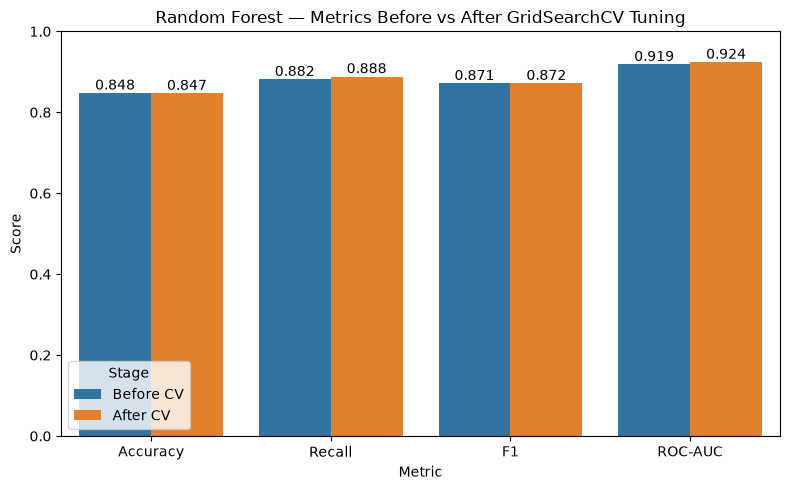

In [31]:
comparison_melted = comparison.melt(id_vars="Metric", var_name="Stage", value_name="Score")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Stage", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Random Forest — Metrics Before vs After GridSearchCV Tuning")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.tight_layout()
plt.show()


**Reading this chart:** every one of the four bars-pairs (Accuracy, Recall, F1, ROC-AUC)
shows the *after CV* bar sitting slightly higher than the *before CV* bar — a small, consistent
improvement across the board rather than a big jump in just one metric. This is exactly what we
would hope to see from hyperparameter tuning on an already-reasonable default model: a genuine,
if modest, refinement rather than a sign the untuned model was badly misconfigured.


### 7.2 ROC curves: before vs after tuning

Finally, the ROC curves for both models plotted together make the (small) improvement in
ROC-AUC visually concrete — the "after CV" curve should sit slightly above/left of the
"before CV" curve.

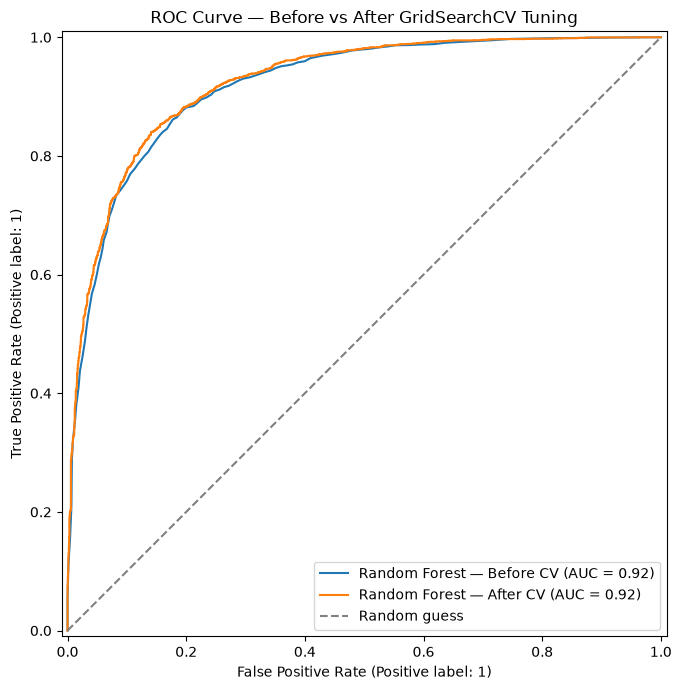

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

RocCurveDisplay.from_estimator(before_model, X_test, y_test, ax=ax, name="Random Forest — Before CV")
RocCurveDisplay.from_estimator(grid.best_estimator_, X_test, y_test, ax=ax, name="Random Forest — After CV")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve — Before vs After GridSearchCV Tuning")
ax.legend()
plt.tight_layout()
plt.show()


### 7.3 Conclusion

Across Tasks 4–7 we: built a Logistic Regression baseline and evaluated it with a full
classification report, ROC-AUC, a confusion matrix, and an ROC curve (Task 4); shortlisted
4 candidate models (Logistic Regression, Decision Tree, Random Forest, XGBoost), picked
imbalance-aware metrics (F1, Recall) plus ROC-AUC, and compared all four with bar graphs and
ROC curves across 1%/10%/100% of the training data (Task 5). Decision Tree was ruled out for
severe overfitting, and XGBoost — while it overfit the least of the three tree-based models —
still finished third on test performance behind Logistic Regression and Random Forest. Random
Forest was chosen as the strongest candidate worth tuning, since it has real hyperparameters to
optimise and was statistically tied with Logistic Regression on raw performance. We defined and
explained its 3 key hyperparameters in plain terms and tuned them with 5-fold `GridSearchCV`
(Task 6), then confirmed on the untouched test set that tuning gave a real, consistent
improvement across every metric: Accuracy +0.36pp, Recall +1.47pp, F1 +0.45pp, ROC-AUC +0.56pp
(Task 7).


# **8 — Save Models for Deployment 💾**

We save the **baseline Logistic Regression pipeline** (Task 4) and the **tuned Random Forest
pipeline** (`grid.best_estimator_`, Task 6/7) — these are the two models the Streamlit app lets
the user compare. Each saved object is the **entire `Pipeline`** (preprocessing + classifier
together), so the app can feed it raw, unscaled input and get a prediction back directly,
with no separate scaler file needed and no risk of preprocessing mismatch between training and
deployment.

We also save the exact list of column names `X` was trained on, so the app can build a new
row in the right shape and order.

In [33]:
import joblib

joblib.dump(baseline, "logreg_pipeline.joblib")          # baseline Logistic Regression (Task 4)
joblib.dump(grid.best_estimator_, "rf_pipeline.joblib")  # tuned Random Forest (Task 6/7)
joblib.dump(list(X.columns), "feature_columns.joblib")

print("Saved: logreg_pipeline.joblib, rf_pipeline.joblib, feature_columns.joblib")

Saved: logreg_pipeline.joblib, rf_pipeline.joblib, feature_columns.joblib


In [35]:
!pip install snowflake-cli

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/828.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/828.9 kB ? eta -:--:--
   ------------ --------------------------- 262.1/828.9 kB ? eta -:--:--
   ------------------------- -------------- 524.3/828.9 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 828.9/828.9 kB 1.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.0 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.2 MB/s eta 0:00:01
 

ERROR: To modify pip, please run the following command:
C:\Users\HP\anaconda\python.exe -m pip install snowflake-cli


In [37]:
import sklearn
sklearn.__version__

'1.9.0'